In [39]:
import rebound
import reboundx
import numpy as np
import matplotlib.pyplot as plt
import trappist1_sim as t1
import warnings
warnings.filterwarnings('ignore')

# Initialize Simulation
sim = rebound.Simulation()
sim.integrator = "whfast" # High precision for close encounters
sim.units = ('yr', 'AU', 'Msun')
sim.dt = 1/40 # yrs

# Add the Star and Planets
# Typical scenario: Two Super-Earths/Mini-Neptunes
sim.add(m=1.0) # Central Star
sim.add(m=1e-5, a=1.8, e=0.01) # Inner Planet (~3 Earth masses)
sim.add(m=1e-5, a=2.8, e=0.01) # Outer Planet

ps = sim.particles
n_planets = 3 # Star + 2 planets

# Add a "Snowplow" population of planetesimals
# We place them exterior to the outer planet
n_planetesimals = 20
a_start = 1.0
a_end = 1.5
for i in range(n_planetesimals):
    # Add as test particles (massless)
    a_rand = np.random.uniform(a_start, a_end)
    sim.add(m=0, a=a_rand, e=0.01, inc=np.random.uniform(0, 0.01))

# Setup migration using REBOUNDx
rebx = reboundx.Extras(sim)
mof = rebx.load_force("modify_orbits_forces")
rebx.add_force(mof)

# Migration parameters
# tau_a: migration timescale (negative means inward)
# tau_e: eccentricity damping timescale (usually 10-100x shorter than tau_a)
ps[1].params["tau_a"] = -1e5  # Inner planet migrates slowly
ps[2].params["tau_a"] = -5e4  # Outer planet migrates faster to catch up
ps[1].params["tau_e"] = -1e3
ps[2].params["tau_e"] = -1e3

# Data Tracking
times = np.linspace(0, 2e5, 500)
data = {name : t1.data_df(500, times) for name in ["p1", "p2"]}
    
p1 = ps[1]
p2 = ps[2]
tp_a = [[] for _ in range(n_planetesimals)]

print("Starting migration phase")
for i, t in enumerate(times):
    sim.integrate(t)    
    
    data["p1"]["a"][i] = p1.a
    data["p2"]["a"][i] = p2.a
    data["p1"]["P_ratio"][i] = p2.P / p1.P
    
    # Track semi-major axis of test particles
    for i in range(n_planetesimals):
        tp_a[i].append(ps[i + n_planets].a)
        
    # Stop migration if planets get too close or hit a resonance lock
    if (p2.P / p1.P) < 1.48: # Just inside the 3:2 resonance
            ps[1].params["tau_a"] = float('inf')
            ps[2].params["tau_a"] = float('inf')

Starting migration phase


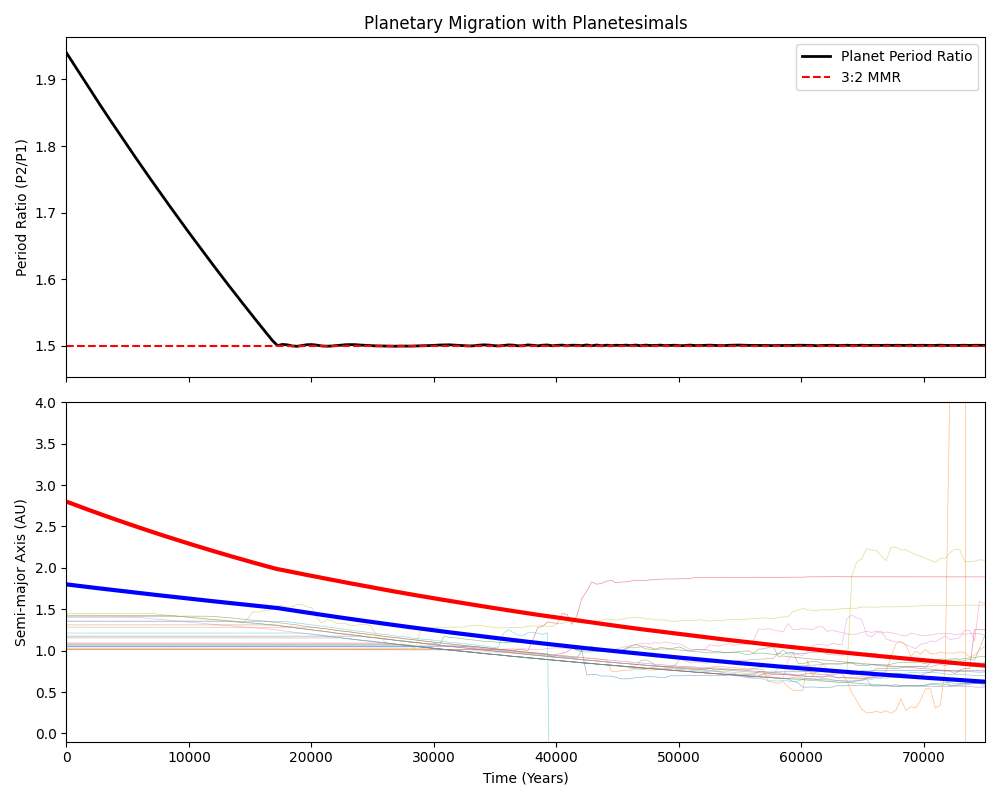

In [42]:
%matplotlib widget
# Plotting the Results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Planet Period Ratio
ax1.plot(times, data["p1"]["P_ratio"], color='black', lw=2, label='Planet Period Ratio')
ax1.axhline(1.5, ls='--', color='red', label='3:2 MMR')
ax1.set_ylabel("Period Ratio (P2/P1)")
ax1.legend()
ax1.set_title("Planetary Migration with Planetesimals")

# Plot Planetesimal Semi-major Axes
for i in range(n_planetesimals):
    ax2.plot(times, tp_a[i], alpha=0.5, lw=0.5)

ax2.plot(times, data["p1"]["a"], color='blue', lw=3, label='Inner Planet') # Note: this is a simplification for plotting
ax2.plot(times, data["p2"]["a"], color='red', lw=3, label='Outer Planet') # Note: this is a simplification for plotting
ax2.set_ylabel("Semi-major Axis (AU)")
ax2.set_xlabel("Time (Years)")
ax2.set_xlim(0, 75000)
ax2.set_ylim(-0.1, 4)

plt.tight_layout()
plt.show()